# File for messing around with FastF1 api

In [42]:
from matplotlib import pyplot as plt
import scipy.interpolate as interp
import pandas as pd
import numpy as np
import fastf1
from fastf1 import plotting
fastf1.plotting.setup_mpl(mpl_timedelta_support=True, color_scheme='fastf1')

## 2026 Barelona GP race pace review

In [3]:
raceNum = 7
year = 2026
seshType = 'R'

session = fastf1.get_session(year, raceNum, seshType)
session.load()

req         WARNING 	DEFAULT CACHE ENABLED! (151.23 MB) /home/ons/.cache/fastf1
core           INFO 	Loading data for Barcelona Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['44', '63', '1', '3'

findfont: Failed to find font weight medium, now using 400.
req            INFO 	Using cached data for driver_info


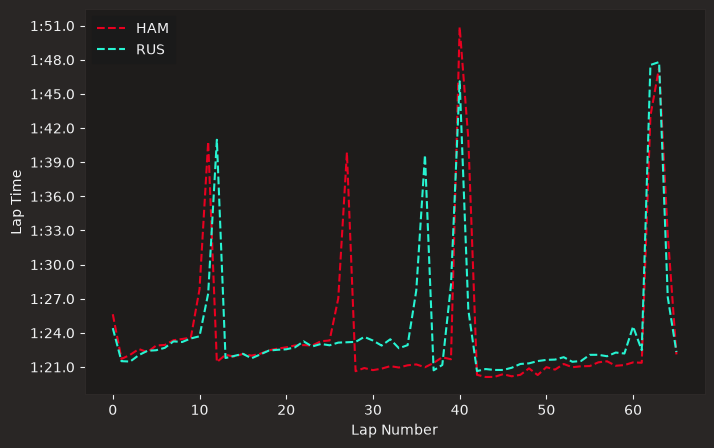

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

for driver in ('HAM', 'RUS'):
    laps = session.laps.pick_drivers(driver).reset_index()
    style = plotting.get_driver_style(identifier=driver,
                                      style=['color', 'linestyle'],
                                      session=session)
    ax.plot(laps['LapTime'], **style, label=driver)

# add axis labels and a legend
ax.set_xlabel("Lap Number")
ax.set_ylabel("Lap Time")
ax.legend()


Text(0.5, 1.0, 'test to see what pick quickest lap does')

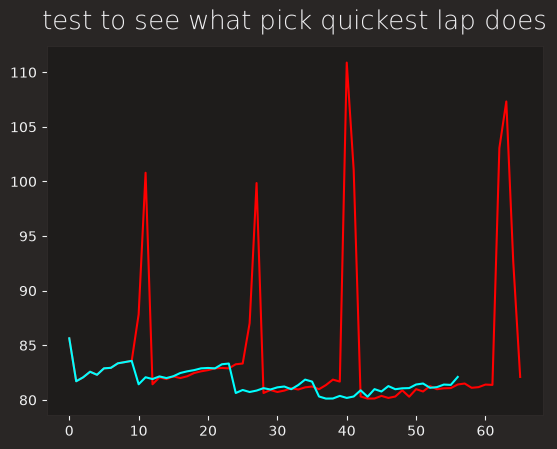

In [9]:
hamLaps = session.laps.pick_drivers('ham').reset_index()['LapTime'].dt.total_seconds()
rusLaps = session.laps.pick_drivers('ham').pick_quicklaps().reset_index()['LapTime'].dt.total_seconds()
plt.plot(hamLaps, color='red')
plt.plot(rusLaps, color='cyan')
plt.title('test to see what pick quickest lap does')

## 2026 Austrian GP Qualfying Fiasco

In [10]:
session = fastf1.get_session(2026, 8, 'q')
session.load()

core           INFO 	Loading data for Austrian Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '16', '44', '12', '3', '1', '81', '6', '30', '41', '10', '5', '87', '27', '31', '43', '55', '23', '11', '77', '14', '18']


In [11]:
rusLap16 = session.laps.pick_drivers('rus').pick_laps(16)
rusLap19 = session.laps.pick_drivers('rus').pick_laps(19)
antLap13 = session.laps.pick_drivers('ant').pick_laps(13)

In [12]:
rusLap16Telem = rusLap16.get_telemetry().add_distance()
rusLap19Telem = rusLap19.get_telemetry().add_distance()
antLap13Telem = antLap13.get_telemetry().add_distance()

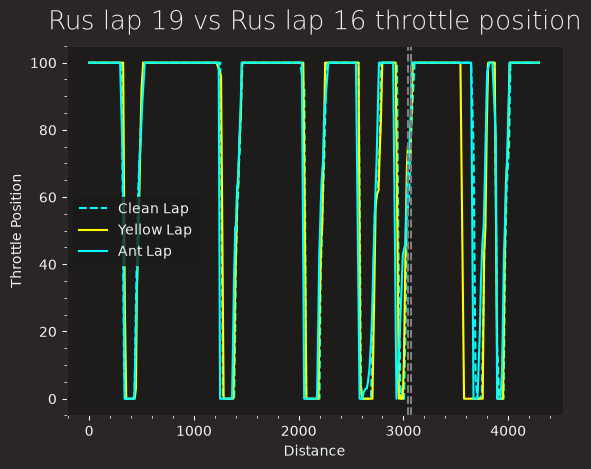

In [60]:
data1 = 'Throttle'

plt.plot(rusLap16Telem['Distance'],rusLap16Telem[data1], '--',color='cyan', label='Clean Lap')
plt.plot(rusLap19Telem['Distance'],rusLap19Telem[data1], '-', color='yellow', label='Yellow Lap')
plt.plot(antLap13Telem['Distance'],antLap13Telem[data1], '-', color='cyan', label='Ant Lap')

plt.xlabel('Distance')
plt.ylabel('Throttle Position')
plt.title('Rus lap 19 vs Rus lap 16 throttle position')
plt.legend()
plt.minorticks_on()
plt.axvline(3040, linestyle='--', color='grey')
plt.axvline(3070, linestyle='--', color='grey')
#plt.xlim(2900,3200)

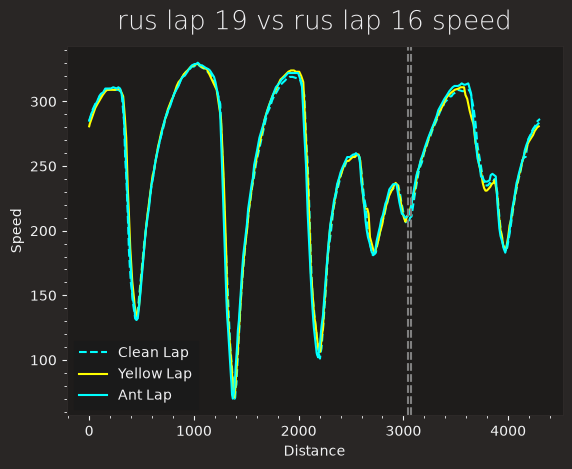

In [61]:
data2 = 'Speed'

plt.plot(rusLap16Telem['Distance'],rusLap16Telem[data2], '--',color='cyan', label='Clean Lap')
plt.plot(rusLap19Telem['Distance'],rusLap19Telem[data2], '-', color='yellow', label='Yellow Lap')
plt.plot(antLap13Telem['Distance'],antLap13Telem[data2], '-', color='cyan', label='Ant Lap')

plt.xlabel('Distance')
plt.ylabel('Speed')
plt.title('rus lap 19 vs rus lap 16 speed')
plt.legend()
plt.minorticks_on()
plt.axvline(3040, linestyle='--', color='grey')
plt.axvline(3070, linestyle='--', color='grey')
#plt.xlim(2900,3200)
#plt.ylim(200,265)


In [45]:
rusLap19Telem['Distance']

2         0.000000
3         7.075000
4        12.841309
5        20.792337
6        45.774559
          ...     
506    4252.660158
507    4261.388133
508    4277.488133
509    4283.172078
510    4291.750932
Name: Distance, Length: 509, dtype: float64

In [49]:
rusSpline19 = interp.make_interp_spline(rusLap19Telem['Distance'], rusLap19Telem['Time'].dt.total_seconds())
rusSpline16 = interp.make_interp_spline(rusLap16Telem['Distance'], rusLap16Telem['Time'].dt.total_seconds())

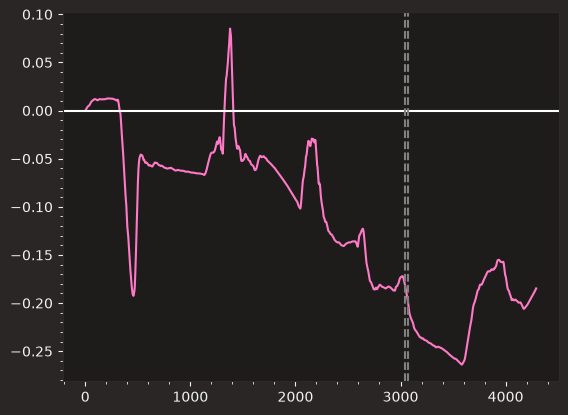

In [62]:
x = np.arange(0, 4292)
plt.plot(x, rusSpline19(x) - rusSpline16(x))
plt.axhline(0, color='White')
plt.axvline(3040, linestyle='--', color='grey')
plt.axvline(3070, linestyle='--', color='grey')
plt.minorticks_on()
#plt.xlim(2500, 4000)
#plt.ylim(-0.275, -0.1)